# 1. Kütüphanelerin İçe Aktarılması ve Ayarlar

In [1]:
!pip install nltk wordcloud spacy
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\imge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\imge\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\imge\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\imge\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
import pandas as pd 
df_reviews=pd.read_json("goodreads_reviews_dedup.json",lines=True,nrows=50000)
print("Yorum verisi boyutu:",df_reviews.shape)
display(df_reviews.head())
print(df_reviews.info())

Yorum verisi boyutu: (50000, 11)


,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
0,8842281e1d1347389f2ab93d60773d4d,24375664,5cd416f3efc3f944fce4ce2db2290d5e,5,Mind blowingly cool. Best science fiction I've...,Fri Aug 25 13:55:02 -0700 2017,Mon Oct 09 08:55:59 -0700 2017,Sat Oct 07 00:00:00 -0700 2017,Sat Aug 26 00:00:00 -0700 2017,16,0
1,8842281e1d1347389f2ab93d60773d4d,18245960,dfdbb7b0eb5a7e4c26d59a937e2e5feb,5,This is a special book. It started slow for ab...,Sun Jul 30 07:44:10 -0700 2017,Wed Aug 30 00:00:26 -0700 2017,Sat Aug 26 12:05:52 -0700 2017,Tue Aug 15 13:23:18 -0700 2017,28,1
2,8842281e1d1347389f2ab93d60773d4d,6392944,5e212a62bced17b4dbe41150e5bb9037,3,I haven't read a fun mystery book in a while a...,Mon Jul 24 02:48:17 -0700 2017,Sun Jul 30 09:28:03 -0700 2017,Tue Jul 25 00:00:00 -0700 2017,Mon Jul 24 00:00:00 -0700 2017,6,0
3,8842281e1d1347389f2ab93d60773d4d,22078596,fdd13cad0695656be99828cd75d6eb73,4,"Fun, fast paced, and disturbing tale of murder...",Mon Jul 24 02:33:09 -0700 2017,Sun Jul 30 10:23:54 -0700 2017,Sun Jul 30 15:42:05 -0700 2017,Tue Jul 25 00:00:00 -0700 2017,22,4
4,8842281e1d1347389f2ab93d60773d4d,6644782,bd0df91c9d918c0e433b9ab3a9a5c451,4,A fun book that gives you a sense of living in...,Mon Jul 24 02:28:14 -0700 2017,Thu Aug 24 00:07:20 -0700 2017,Sat Aug 05 00:00:00 -0700 2017,Sun Jul 30 00:00:00 -0700 2017,8,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       50000 non-null  object
 1   book_id       50000 non-null  int64 
 2   review_id     50000 non-null  object
 3   rating        50000 non-null  int64 
 4   review_text   50000 non-null  object
 5   date_added    50000 non-null  object
 6   date_updated  50000 non-null  object
 7   read_at       50000 non-null  object
 8   started_at    50000 non-null  object
 9   n_votes       50000 non-null  int64 
 10  n_comments    50000 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 4.2+ MB
None


# 2. Veri Yükleme ve Metin Ön İşleme (Text Preprocessing)
* Veri setinden örneklem alınması.
* Noktalama işaretleri, sayılar ve anlamsız bağlaçların temizlenmesi.
# 3. Keşifsel Veri Analizi ve Görselleştirme (EDA)
* Kitap puanlarının dağılımı.
* Okur yorumlarında en çok geçen kelimelerin analizi.

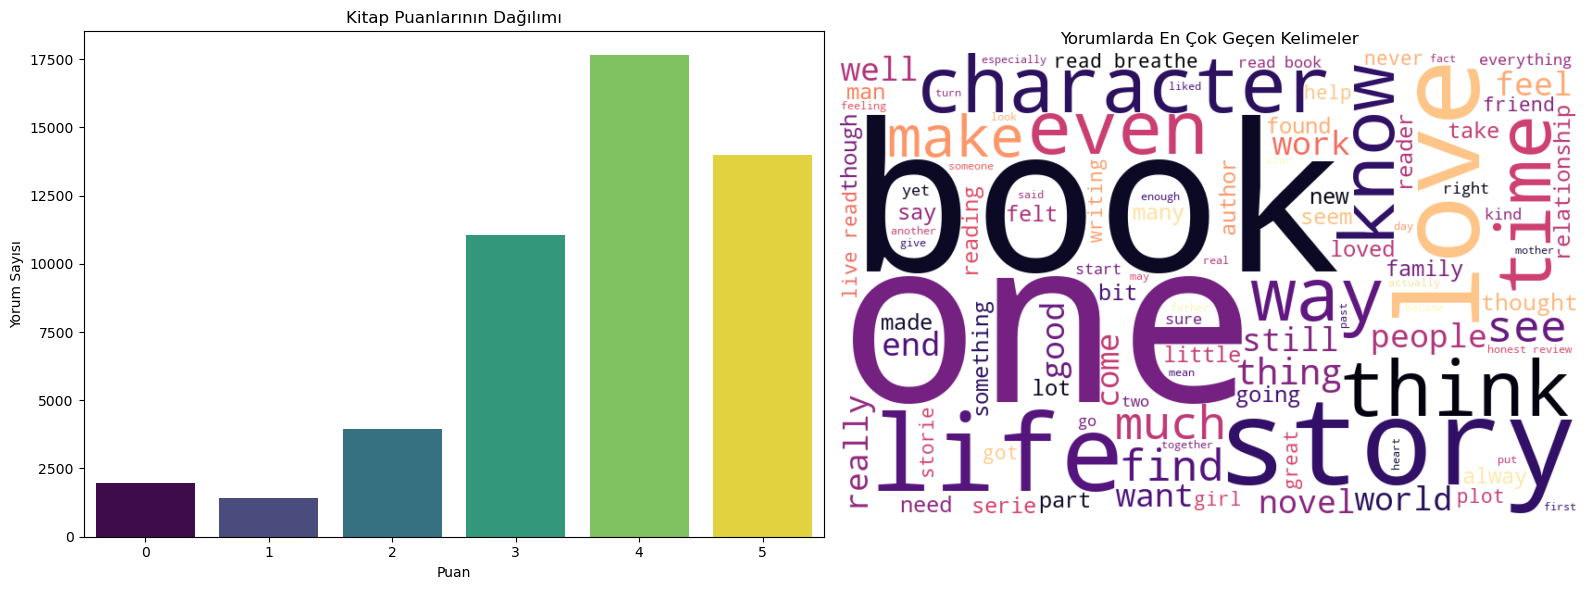

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords

stop_words=set(stopwords.words("english"))

def clean_text(text):
    text=re.sub("^a-zA-Z]"," ",str(text))
    text=text.lower()
    words=text.split()
    cleaned_words=[w for w in words if w not in stop_words]
    return " ".join(cleaned_words)

df_reviews["cleaned_text"]=df_reviews["review_text"].apply(clean_text)

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.countplot(x="rating",data=df_reviews,palette="viridis",hue='rating', legend=False)
plt.title("Kitap Puanlarının Dağılımı")
plt.xlabel("Puan")
plt.ylabel("Yorum Sayısı")

plt.subplot(1,2,2)
all_words=" ".join(df_reviews["cleaned_text"])
wordcloud=WordCloud(width=800,height=500,background_color="white",
                    max_words=100,colormap="magma").generate(all_words)
plt.imshow(wordcloud,interpolation="bilinear")
plt.title("Yorumlarda En Çok Geçen Kelimeler")
plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

tfidf_matrix=tfidf.fit_transform(df_reviews["cleaned_text"])

print("Matris Boyutu:",tfidf_matrix.shape)
print(tfidf_matrix[0].toarray())

Matris Boyutu: (50000, 5000)
[[0. 0. 0. ... 0. 0. 0.]]


# 4. Yapay Zeka ile Duygu Analizi 
* Kelimelerin TF-IDF ile vektörizasyonu.
* Makine öğrenmesi modeli ile yorumların pozitif/negatif olarak sınıflandırılması.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

df_model=df_reviews[df_reviews["rating"]!=3].copy()
df_model["sentiment"]=df_model["rating"].apply(lambda x:1 if x>=4 else 0)

X=tfidf.transform(df_model["cleaned_text"])
y=df_model["sentiment"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
print(f"Model Başarı Oranı:&_%{accuracy_score(y_test,y_pred)*100:.2f}")
print(classification_report(y_test,y_pred))

Model Başarı Oranı:&_%87.80
              precision    recall  f1-score   support

           0       0.84      0.42      0.56      1443
           1       0.88      0.98      0.93      6347

    accuracy                           0.88      7790
   macro avg       0.86      0.70      0.75      7790
weighted avg       0.87      0.88      0.86      7790



# 5. Kitap Tavsiye Motorunun İnşası 
* Yorumların kitap bazında birleştirilerek "Kitap Profilleri" oluşturulması.
* Kosinüs Benzerliği (Cosine Similarity) ile kitaplar arası mesafenin ölçülmesi.

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

book_profiles=df_reviews.groupby("book_id")["cleaned_text"].apply(lambda x:" ".join(x)).reset_index()

tfidf_book=TfidfVectorizer(max_features=5000)
book_matrix=tfidf_book.fit_transform(book_profiles["cleaned_text"])

cosine_sim=cosine_similarity(book_matrix,book_matrix)

print("-"*30)
print("Sistemdeki benzersiz kitap sayısı:",book_profiles.shape[0])
print("Benzerlik Matrisi Boyutu:",cosine_sim.shape)


------------------------------
Sistemdeki benzersiz kitap sayısı: 36742
Benzerlik Matrisi Boyutu: (36742, 36742)


In [7]:
def get_recommendations(book_index,cosine_sim=cosine_sim):
    sim_scores=list(enumerate(cosine_sim[book_index]))
    sim_scores=sorted(sim_scores,key=lambda x:[1],reverse=True)
    sim_scores=sim_scores[1:6]
    book_indices=[i[0] for i in sim_scores]
    return book_profiles.iloc[book_indices]

secilen_kitap_id=book_profiles.iloc[0]["book_id"]
print(f"Seçilen Kitap ID:{secilen_kitap_id}")
print("\nBu kitabı sevenler için öneri:")
display(get_recommendations(0))

Seçilen Kitap ID:1

Bu kitabı sevenler için öneri:


,book_id,cleaned_text
1,2,"first read, book worst one harry potter series..."
2,3,tuve el gusto de leerlo antes de que saliera l...
3,5,"one definitely good second one. much happened,..."
4,6,"best harry potter book far, followed closely b..."
5,11,"good book sick bed, subway commute. douglas ad..."


# 6. Metadata Entegrasyonu ve Final Sonuçları
* ID numaralarının gerçek kitap isimleri ve yazar bilgileriyle eşleştirilmesi.
* Sistemin test edilmesi.

In [8]:
import pandas as pd

cols_to_use=["book_id","title","authors","average_rating"]
metadata=pd.read_json("goodreads_books.json",lines=True,
                      orient="records",
                      chunksize=100000)
our_book_ids=set(book_profiles["book_id"].astype(str))
book_details=[]

for chunk in metadata:
    filtered_chunk=chunk[chunk["book_id"].astype(str).isin(our_book_ids)]
    book_details.append(filtered_chunk[cols_to_use])

df_titles=pd.concat(book_details)

display(df_titles.head())

,book_id,title,authors,average_rating
3,6066819,Best Friends Forever,"[{'author_id': '9212', 'role': ''}]",3.49
11,33394837,The House of Memory (Pluto's Snitch #2),"[{'author_id': '242185', 'role': ''}]",4.33
15,89375,90 Minutes in Heaven: A True Story of Death an...,"[{'author_id': '39054', 'role': ''}, {'author_...",3.91
89,780918,"Rite of Conquest (William the Conqueror, #1)","[{'author_id': '41194', 'role': ''}]",3.43
115,22642971,The Body Electric,"[{'author_id': '4018722', 'role': ''}]",3.71


In [9]:
def get_recommendations_with_titles(book_index):
    sim_scores=list(enumerate(cosine_sim[book_index]))
    sim_scores=sorted(sim_scores,key=lambda x: x[1],reverse=True)
    sim_scores=sim_scores[1:6]

    indices=[i[0] for i in sim_scores]
    recommended_ids=book_profiles.iloc[indices]["book_id"].astype(str)

    results=df_titles[df_titles["book_id"].astype(str).isin(recommended_ids)]
    return results[["title","average_rating"]]

display(get_recommendations_with_titles(0))

,title,average_rating
1028676,Harry Potter and the Prisoner of Azkaban (Harr...,4.53
1628226,Harry Potter and the Deathly Hallows (Harry Po...,4.62
1794298,Harry Potter and the Chamber of Secrets (Harry...,4.38
2083381,Harry Potter and the Order of the Phoenix (Har...,4.47
2251360,Harry Potter and the Goblet of Fire (Harry Pot...,4.53


In [11]:
import pickle 
import scipy.sparse

df_titles.to_pickle("book_titles.pkl")
book_profiles.to_pickle("book_profiles.pkl")

scipy.sparse.save_npz("tfidf_book_matrix.npz",book_matrix)

print("İşlem bitti.")

İşlem bitti.
